In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
import joblib



In [29]:
# Load data
df = pd.read_csv('cleaned_data.csv')

In [30]:
# select only numeric features
numeric_features = ['Engine HP', 'Engine Cylinders', 'highway MPG', 
                    'city mpg', 'Year', 'Popularity', 'Avg MPG']

In [31]:

# Check which features exist
available_features = [f for f in numeric_features if f in df.columns]
print(f"Available features: {available_features}")

X = df[available_features].copy()
y = df['MSRP']

# Handle missing values
X = X.fillna(X.median())
y = y.fillna(y.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Available features: ['Engine HP', 'Engine Cylinders', 'highway MPG', 'city mpg', 'Year', 'Popularity', 'Avg MPG']


In [32]:
# Train simple model
model1= RandomForestRegressor(n_estimators=100, random_state=42)
model1.fit(X_train, y_train)

model2 = LinearRegression()
model2.fit(X_train, y_train)

model3 = XGBRegressor(random_state=42)
model3.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [33]:
# Predict on test set
y_pred1 = model1.predict(X_test)

# Calculate metrics
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1 = r2_score(y_test, y_pred1)
mae1 = mean_absolute_error(y_test, y_pred1)

print(f"R² Score: {r2_1:.3f}")
print(f"RMSE : {rmse1:.3f}")
print(f"Mean Absolute Error: {mae1:.3f}")




R² Score: 0.944
RMSE : 3813.183
Mean Absolute Error: 2660.976


In [34]:
# Predict on test set
y_pred2 = model2.predict(X_test)

# Calculate metrics
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2 = r2_score(y_test, y_pred2)
mae2 = mean_absolute_error(y_test, y_pred2)

print(f"R² Score: {r2_2:.3f}")
print(f"RMSE: {rmse2:.3f}")
print(f"Mean Absolute Error: {mae2:.3f}")

R² Score: 0.740
RMSE: 8185.606
Mean Absolute Error: 6364.064


In [35]:
# Predict on test set
y_pred3 = model3.predict(X_test)

# Calculate metrics
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r2_3 = r2_score(y_test, y_pred3)
mae3 = mean_absolute_error(y_test, y_pred3)

print(f"R² Score: {r2_3:.3f}")
print(f"RMSE: {rmse3:.3f}")
print(f"Mean Absolute Error: {mae3:.3f}")

R² Score: 0.949
RMSE: 3620.832
Mean Absolute Error: 2541.302


In [36]:
# Store results 
results = {
    'Model': ['Random Forest', 'Linear Regression', 'XGBoost'],
    'RMSE': [rmse1, rmse2, rmse3],
    'R²': [r2_1, r2_2, r2_3],
    'MAE': [mae1, mae2, mae3]
}


# Convert to DataFrame and print
df_results = pd.DataFrame(results)
print(df_results.round(2))

               Model     RMSE    R²      MAE
0      Random Forest  3813.18  0.94  2660.98
1  Linear Regression  8185.61  0.74  6364.06
2            XGBoost  3620.83  0.95  2541.30


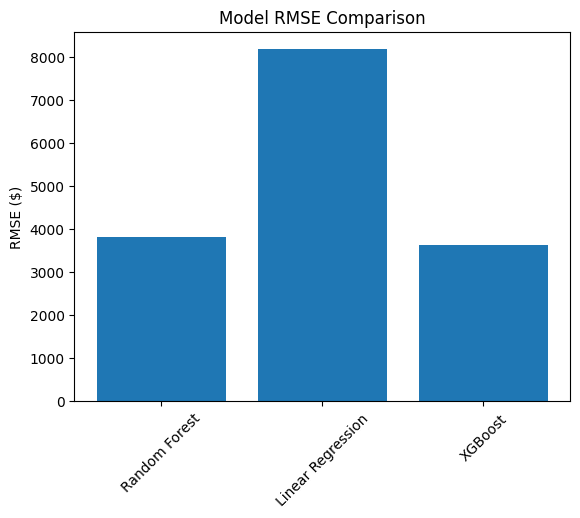

In [37]:
# Bar chart for RMSE comparison
plt.bar(results['Model'], results['RMSE'])
plt.title('Model RMSE Comparison')
plt.ylabel('RMSE ($)')
plt.xticks(rotation=45)
plt.show()

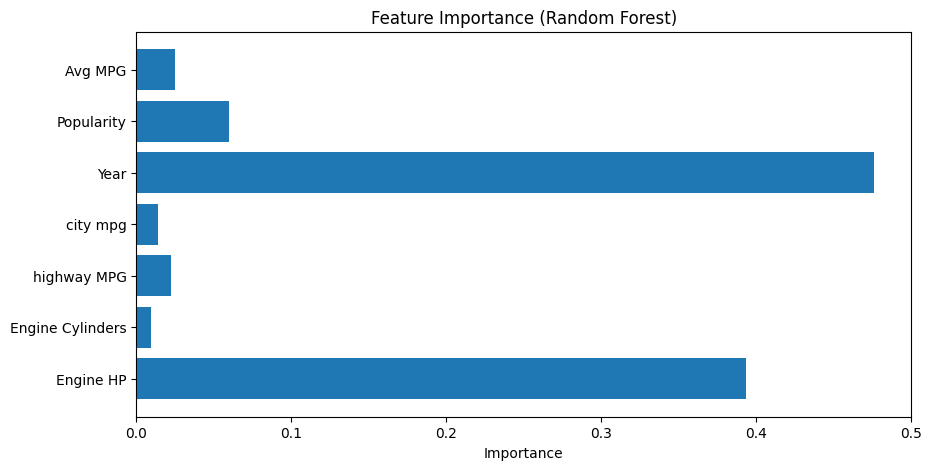

In [38]:
importances = model1.feature_importances_
features = X.columns

plt.figure(figsize=(10, 5))
plt.barh(features, importances)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

In [40]:
# Save best model
joblib.dump(model3, 'price_predictor.pkl')
print("Model saved as price_predictor.pkl")

Model saved as price_predictor.pkl


In [41]:
def predict_price(engine_hp, cylinders, highway_mpg, city_mpg, year, popularity):
    """
    Predict car price based on features
    """
    # Load model
    model = joblib.load('price_predictor.pkl')
    
    # Calculate Avg MPG
    avg_mpg = (highway_mpg + city_mpg) / 2
    
    # Create input array
    input_data = np.array([[engine_hp, cylinders, highway_mpg, city_mpg, 
                            year, popularity, avg_mpg]])
    
    # Predict
    predicted_price = model.predict(input_data)[0]
    
    return predicted_price

# Example usage
price = predict_price(
    engine_hp=300,
    cylinders=6,
    highway_mpg=28,
    city_mpg=20,
    year=2016,
    popularity=1500
)
print(f"Predicted Price: ${price:,.0f}")

Predicted Price: $34,045
